<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/Project11_HeartDisease_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# Project 11 - Heart Disease Prediction
# Dataset: Heart Disease UCI
# Source: Kaggle
# Domain: Healthcare
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [3]:
import os
print(os.listdir())


['.config', 'HeartDiseaseTrain-Test.csv', 'sample_data']


In [4]:
# ================================
# Step 1 - Upload Dataset
# ================================

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('HeartDiseaseTrain-Test.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())


Saving HeartDiseaseTrain-Test.csv to HeartDiseaseTrain-Test (1).csv
Dataset loaded successfully!
Shape: (1025, 14)
   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope v

Shape: (1025, 14)

Missing Values: 0

Target Distribution:
target
1    526
0    499
Name: count, dtype: int64


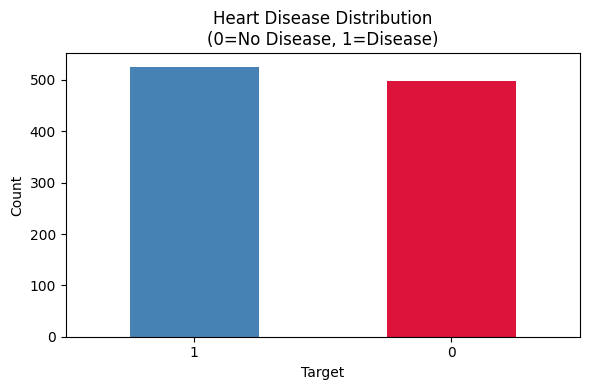

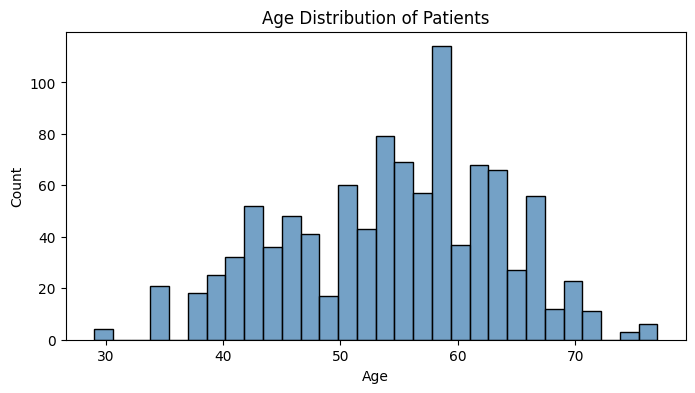

Plots ready!


In [5]:
# ================================
# Step 2 - EDA
# ================================

print("Shape:", df.shape)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nTarget Distribution:")
print(df['target'].value_counts())

# Plot 1: Heart Disease Distribution
plt.figure(figsize=(6,4))
df['target'].value_counts().plot(kind='bar', color=['steelblue','crimson'])
plt.title('Heart Disease Distribution\n(0=No Disease, 1=Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.show()

print("Plots ready!")


In [6]:
# ================================
# Step 3 - Preprocessing & Models
# ================================

# Encode categorical columns
df_encoded = pd.get_dummies(df)

# Features & Target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Model Results:")
print("="*50)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))
    print(f"ROC-AUC: {auc:.4f}")


Model Results:

Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.89      0.83      0.86       100
     Disease       0.85      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205

ROC-AUC: 0.9446

Decision Tree
              precision    recall  f1-score   support

  No Disease       0.90      0.87      0.88       100
     Disease       0.88      0.90      0.89       105

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205

ROC-AUC: 0.9220

Random Forest
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1

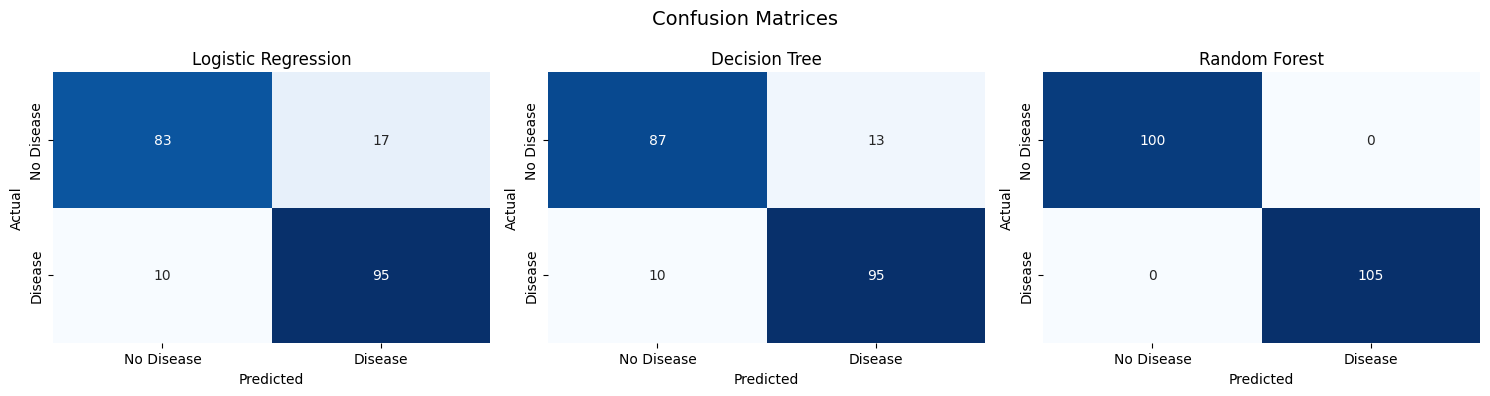

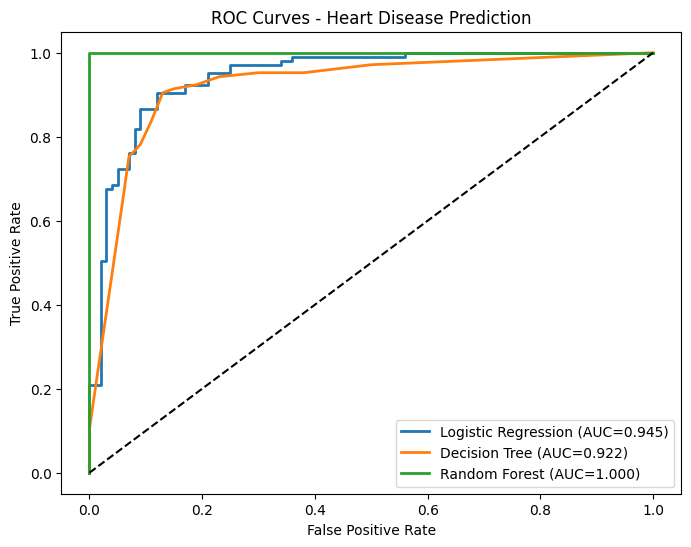

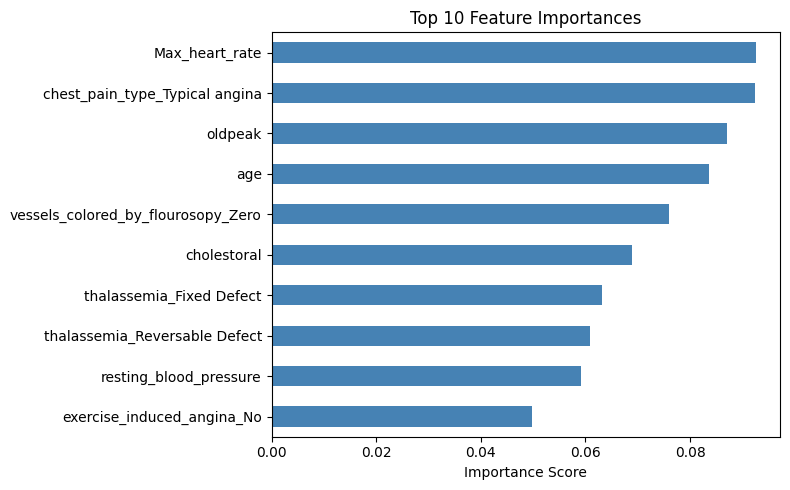

Project Complete!


In [7]:
# ================================
# Step 4 - Final Visualizations
# ================================

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Heart Disease Prediction')
plt.legend()
plt.show()

# Feature Importance
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)
plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Project Complete!")
